In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os
import sys


In [2]:
# Example JSON file
file_path = 'results.json'

# Using json.load() to parse JSON data from file
with open(file_path, 'r') as file:
    data = json.load(file)


In [3]:
# Convert the dictionary to a pandas DataFrame
df = pd.DataFrame.from_dict(data, orient='index')

# Rename the index to a regular column called 'query'
df.reset_index(inplace=True)
df.rename(columns={'index': 'query'}, inplace=True)

# Display the DataFrame
df.head()

,query,result,response_time,topic
0,Tell me something about computers,Timeline of computing presents events in the h...,16292.580128,Technology
1,Tell me something about pizza,The annunciation to the shepherds is an episod...,11799.002171,Food
2,Tell me something about Finance,The Ministry of Economics and Finance is one o...,2674.728870,Economy
3,Basketball,"Adrian Wojnarowski (born March 4, 1969) is an ...",5161.508799,Sports
4,Heart,Bryan Health is an American not-for-profit hea...,2010.826111,Health


In [4]:

# # Display results to the user
# # import ace_tools as tools; tools.display_dataframe_to_user(name="DataFrame for Queries and Response Analysis", dataframe=df)

# # Plotting
# # Count plot for topics
# plt.figure(figsize=(8, 5))
# topic_counts.plot(kind="bar")
# plt.title("Count of Topics")
# plt.xlabel("Topic")
# plt.ylabel("Count")
# plt.xticks(rotation=45)
# plt.show()

# # Histogram for result lengths
# plt.figure(figsize=(8, 5))
# plt.hist(df["result_length"], bins=25, density=True, alpha=0.7, edgecolor='black')
# plt.title("Histogram/PDF of Result Lengths")
# plt.xlabel("Length of Result")
# plt.ylabel("Density")
# plt.show()

# import seaborn as sns

# # KDE plot for result lengths
# plt.figure(figsize=(8, 5))
# sns.kdeplot(df["result_length"], shade=True, color="orange", alpha=0.7)
# plt.title("Smooth Distribution of Result Lengths (KDE)")
# plt.xlabel("Length of Result")
# plt.ylabel("Density")
# plt.show()


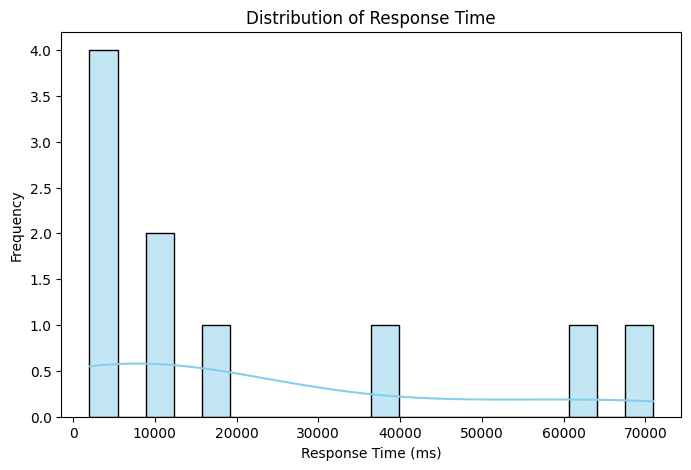

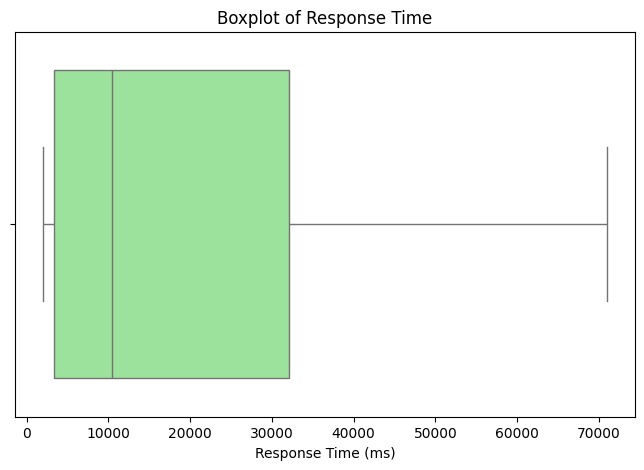

/tmp/ipykernel_122186/3144471436.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='topic', data=df, palette='Set3')


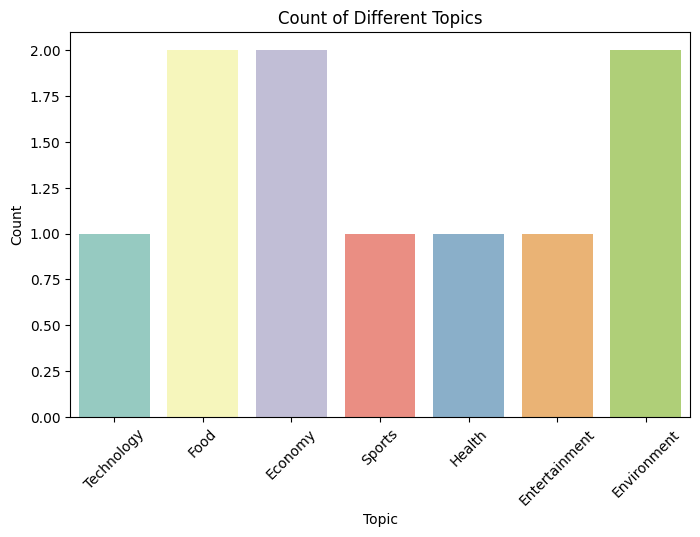

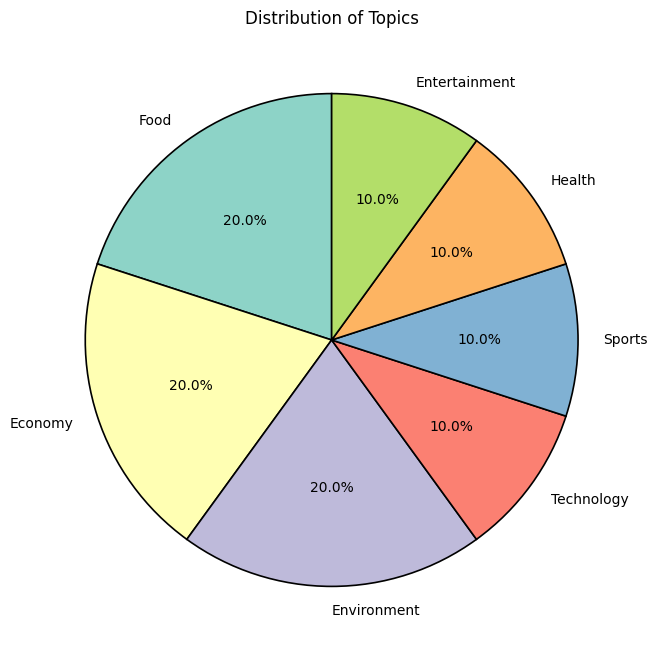

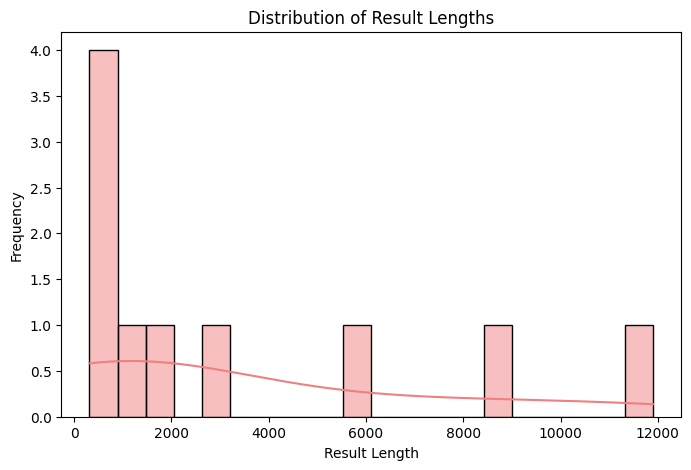

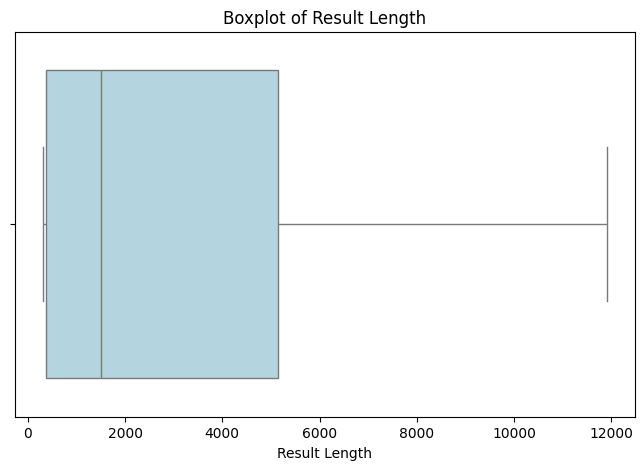

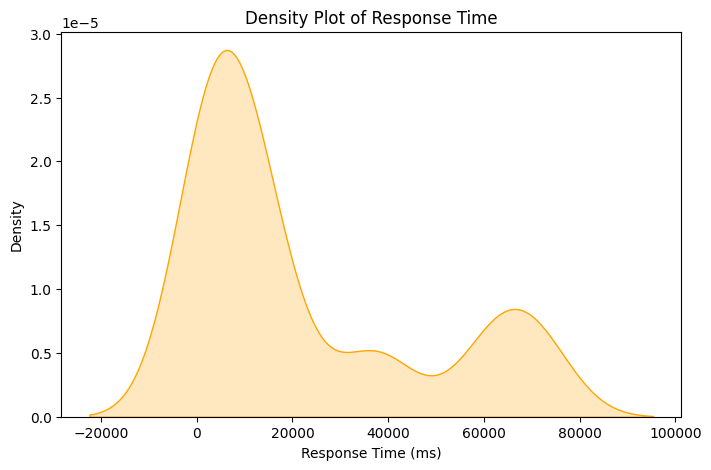

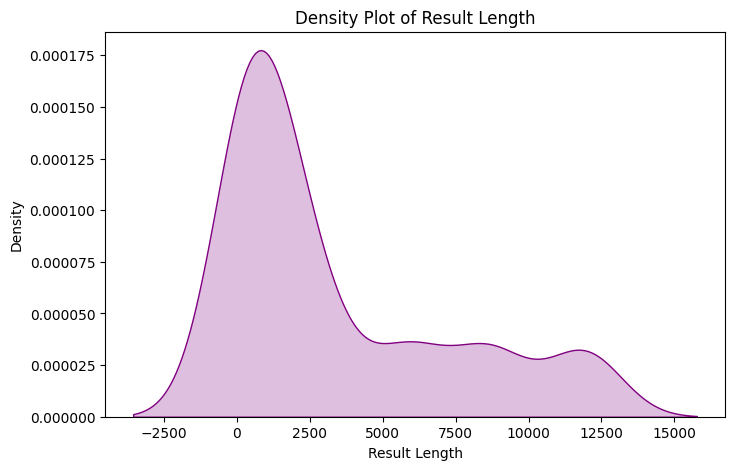

In [7]:
import os

# Create a folder for the visualizations if it doesn't already exist
output_folder = "visualization_plots"
os.makedirs(output_folder, exist_ok=True)

df['result_length'] = df['result'].apply(len)


# 1. Histogram for response_time
plt.figure(figsize=(8, 5))
sns.histplot(df['response_time'], kde=True, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Response Time')
plt.xlabel('Response Time (ms)')
plt.ylabel('Frequency')
plt.savefig(os.path.join(output_folder, 'response_time_histogram.png'))
plt.show()
plt.close()

# 2. Boxplot for response_time
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['response_time'], color='lightgreen')
plt.title('Boxplot of Response Time')
plt.xlabel('Response Time (ms)')
plt.savefig(os.path.join(output_folder, 'response_time_boxplot.png'))
plt.show()
plt.close()

# 3. Bar Plot for topic counts
plt.figure(figsize=(8, 5))
sns.countplot(x='topic', data=df, palette='Set3')
plt.title('Count of Different Topics')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig(os.path.join(output_folder, 'topic_barplot.png'))
plt.show()
plt.close()

# 4. Pie chart for topic distribution
topic_counts = df['topic'].value_counts()
plt.figure(figsize=(8, 8))
topic_counts.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette("Set3", len(topic_counts)),
                  startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})
plt.title('Distribution of Topics')
plt.ylabel('')
plt.savefig(os.path.join(output_folder, 'topic_piechart.png'))
plt.show()
plt.close()

# 5. Histogram for result_length
plt.figure(figsize=(8, 5))
sns.histplot(df['result_length'], kde=True, bins=20, color='lightcoral', edgecolor='black')
plt.title('Distribution of Result Lengths')
plt.xlabel('Result Length')
plt.ylabel('Frequency')
plt.savefig(os.path.join(output_folder, 'result_length_histogram.png'))
plt.show()
plt.close()

# 6. Boxplot for result_length
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['result_length'], color='lightblue')
plt.title('Boxplot of Result Length')
plt.xlabel('Result Length')
plt.savefig(os.path.join(output_folder, 'result_length_boxplot.png'))
plt.show()
plt.close()

# 7. Density Plot (KDE) for response_time
plt.figure(figsize=(8, 5))
sns.kdeplot(df['response_time'], fill=True, color='orange', bw_adjust=0.5)
plt.title('Density Plot of Response Time')
plt.xlabel('Response Time (ms)')
plt.ylabel('Density')
plt.savefig(os.path.join(output_folder, 'response_time_kde.png'))
plt.show()
plt.close()

# 8. Density Plot (KDE) for result_length
plt.figure(figsize=(8, 5))
sns.kdeplot(df['result_length'], fill=True, color='purple', bw_adjust=0.5)
plt.title('Density Plot of Result Length')
plt.xlabel('Result Length')
plt.ylabel('Density')
plt.savefig(os.path.join(output_folder, 'result_length_kde.png'))
plt.show()
plt.close()

